# 02 — CFD vs. rCFD Quantitative Analysis

Reproduces the validated Step 1 comparison. Driven by `scripts/compare_cfd_rcfd.py`.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve() / 'scripts'))
from cfdio import parse_fluent_out
import numpy as np, matplotlib.pyplot as plt

RAW = pathlib.Path('..') / 'data' / 'raw'
cfd = parse_fluent_out(RAW / 'CFD_temperature.out')
rcfd = parse_fluent_out(RAW / 'rCFD_temperature.out')
n = min(len(cfd), len(rcfd))
T_cfd, T_rcfd = cfd[-n:, 1], rcfd[-n:, 1]
t = rcfd[-n:, 0]
abs_err = np.abs(T_rcfd - T_cfd)
print(f'MAE = {abs_err.mean():.2f} K   max = {abs_err.max():.2f} K   N = {n}')

MAE = 4.78 K   max = 16.70 K   N = 601


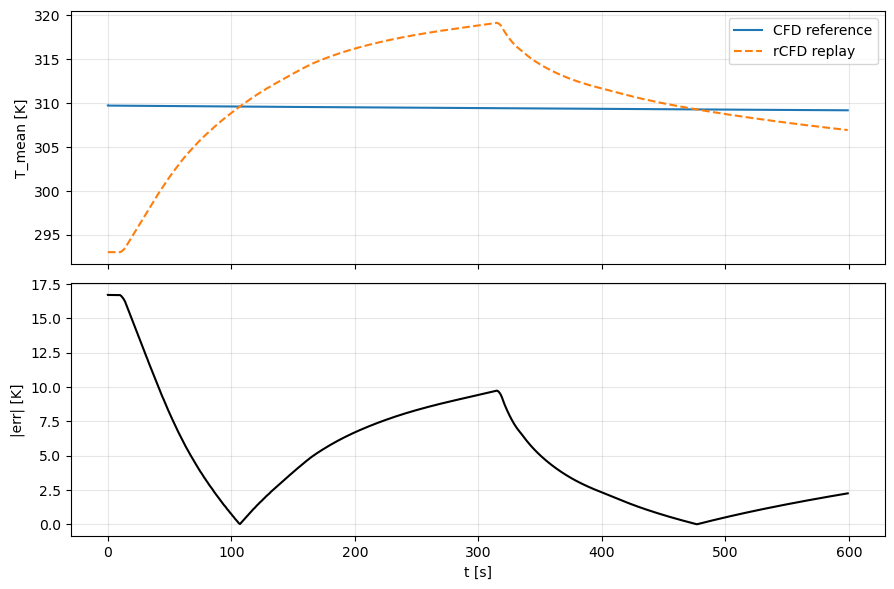

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(t, T_cfd, label='CFD reference')
axes[0].plot(t, T_rcfd, '--', label='rCFD replay')
axes[0].set_ylabel('T_mean [K]'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(t, abs_err, color='k')
axes[1].set_xlabel('t [s]'); axes[1].set_ylabel('|err| [K]'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()